In [1]:
import pandas as pd
import numpy as np

In [2]:
playlist = pd.read_csv("phase5_model_development/dataset/playlist_with_segment.csv")

In [3]:
cluster_1 = playlist[playlist['cluster'] == 1]
cluster_1 = cluster_1[cluster_1['dataset_type'] == "train"]
cluster_1['sentiment_centroid'] = cluster_1['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

In [4]:
import pandas as pd
import numpy as np

# Convert to 2D NumPy array
sentiment_vectors = np.vstack(cluster_1['sentiment_centroid'])

# Compute dot product matrix
dot_product_matrix = np.dot(sentiment_vectors, sentiment_vectors.T)

# Display results
matrix = pd.DataFrame(dot_product_matrix, index=cluster_1['playlist_idx'], columns=cluster_1['playlist_idx'])
print(matrix)

playlist_idx     1         6         18        23        24        34     \
playlist_idx                                                               
1             0.181888  0.191394  0.186009  0.186069  0.187941  0.187834   
6             0.191394  0.207840  0.198265  0.198375  0.201331  0.201209   
18            0.186009  0.198265  0.193040  0.192170  0.194001  0.194402   
23            0.186069  0.198375  0.192170  0.192192  0.193722  0.193874   
24            0.187941  0.201331  0.194001  0.193722  0.197107  0.197037   
...                ...       ...       ...       ...       ...       ...   
19971         0.189467  0.203980  0.197001  0.196723  0.198672  0.198950   
19975         0.188618  0.202204  0.195813  0.195280  0.197795  0.198027   
19976         0.190695  0.205684  0.197395  0.197749  0.200061  0.199982   
19995         0.190442  0.205008  0.196954  0.197197  0.200122  0.200003   
19996         0.185775  0.197988  0.191859  0.191550  0.193486  0.193631   

playlist_id

In [ ]:
# Find the pair with the minimum similarity (excluding diagonal)
min_similarity = matrix.min().min()
min_indices = matrix.stack().idxmin()

# Display the result
print(f"Lowest similarity is between playlist {min_indices[0]} and playlist {min_indices[1]}: {min_similarity}")

Lowest similarity is between playlist 12869 and playlist 10179: 0.24293500827202308


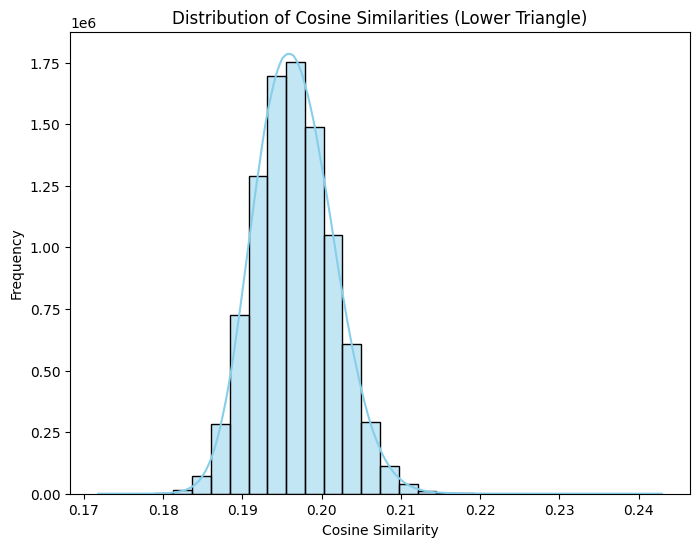

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Set diagonal to NaN or ignore it to focus on the lower triangle
matrix = matrix.where(np.tril(np.ones(matrix.shape), k=-1).astype(bool))

# Flatten the lower triangle into a 1D array
lower_triangle_values = matrix.stack().values

# Plot the distribution of the lower triangle values
plt.figure(figsize=(8, 6))
sns.histplot(lower_triangle_values, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Cosine Similarities (Lower Triangle)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

In [4]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.preprocessing import StandardScaler

# Convert string representations into NumPy arrays
# cluster_1['sentiment_centroid'] = cluster_1['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert to 2D NumPy array
sentiment_vectors = np.vstack(cluster_1['sentiment_centroid'])

# # Scale the vectors (if needed)
# scaler = StandardScaler()
# sentiment_vectors_scaled = scaler.fit_transform(sentiment_vectors)

# Compute Euclidean distance matrix
euclidean_dist_matrix = euclidean_distances(sentiment_vectors) 

# Create a DataFrame for better readability
distance_matrix = pd.DataFrame(euclidean_dist_matrix, index=cluster_1['playlist_idx'], columns=cluster_1['playlist_idx'])

# Find the minimum distance pair (excluding the diagonal)
np.fill_diagonal(euclidean_dist_matrix, np.inf)  # Temporarily set diagonal to inf
min_idx = np.unravel_index(np.argmin(euclidean_dist_matrix), euclidean_dist_matrix.shape)

# Get the playlist indices for the least similar pair
playlist_1 = cluster_1['playlist_idx'].iloc[min_idx[0]]
playlist_2 = cluster_1['playlist_idx'].iloc[min_idx[1]]
min_distance = euclidean_dist_matrix[min_idx]

# Display result
print(f"Lowest Euclidean distance is between playlist {playlist_1} and playlist {playlist_2}: {min_distance}")

Lowest Euclidean distance is between playlist 9564 and playlist 12396: 0.0011107462259562074


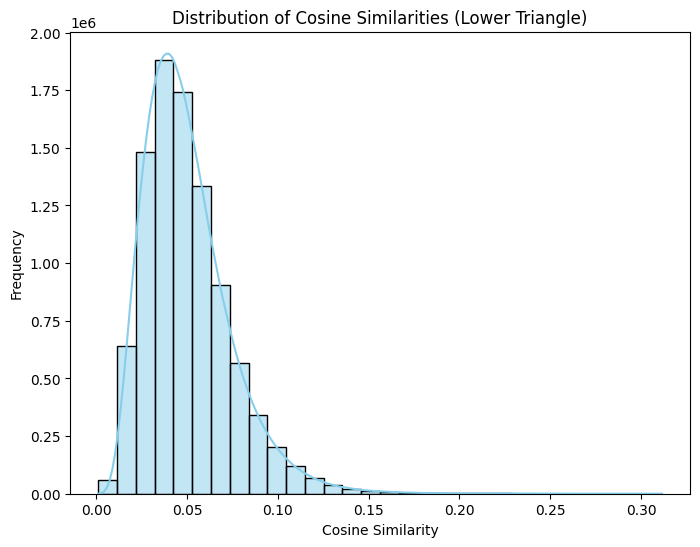

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

# Set diagonal to NaN or ignore it to focus on the lower triangle
distance_matrix = distance_matrix.where(np.tril(np.ones(distance_matrix.shape), k=-1).astype(bool))

# Flatten the lower triangle into a 1D array
lower_triangle_values = distance_matrix.stack().values

# Plot the distribution of the lower triangle values
plt.figure(figsize=(8, 6))
sns.histplot(lower_triangle_values, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Cosine Similarities (Lower Triangle)')
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.show()

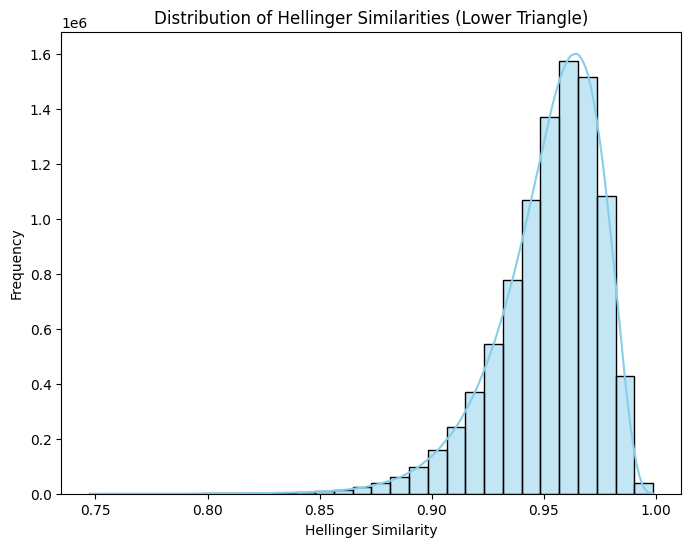

In [29]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

# Define function to calculate Hellinger distance
def hellinger_distance(P, Q):
    return np.sqrt(0.5 * np.sum((np.sqrt(P) - np.sqrt(Q))**2))

# Define function to calculate Hellinger similarity
def hellinger_similarity(P, Q):
    return 1 - hellinger_distance(P, Q)

# Assuming you have a DataFrame `matrix` and each row is a probability vector (e.g., sentiment centroid)

# Extract sentiment vectors from the 'sentiment_centroid' column (make sure it's a numpy array or list)
sentiment_vectors = np.vstack(cluster_1['sentiment_centroid'])

# Compute Hellinger similarity matrix (pairwise)
hellinger_sim_matrix = np.zeros((sentiment_vectors.shape[0], sentiment_vectors.shape[0]))

for i in range(sentiment_vectors.shape[0]):
    for j in range(i + 1, sentiment_vectors.shape[0]):
        hellinger_sim_matrix[i, j] = hellinger_similarity(sentiment_vectors[i], sentiment_vectors[j])
        hellinger_sim_matrix[j, i] = hellinger_sim_matrix[i, j]  # Symmetric matrix

# Convert to DataFrame for easier handling
hellinger_sim_df = pd.DataFrame(hellinger_sim_matrix, index=cluster_1['playlist_idx'], columns=cluster_1['playlist_idx'])

# Set diagonal to NaN or ignore it to focus on the lower triangle
hellinger_sim_df = hellinger_sim_df.where(np.tril(np.ones(hellinger_sim_df.shape), k=-1).astype(bool))

# Flatten the lower triangle into a 1D array
lower_triangle_values_hellinger = hellinger_sim_df.stack().values

# Plot the distribution of the lower triangle values (Hellinger Similarity)
plt.figure(figsize=(8, 6))
sns.histplot(lower_triangle_values_hellinger, kde=True, bins=30, color='skyblue')
plt.title('Distribution of Hellinger Similarities (Lower Triangle)')
plt.xlabel('Hellinger Similarity')
plt.ylabel('Frequency')
plt.show()

In [32]:
import pandas as pd
import numpy as np
from scipy.special import rel_entr  # Computes element-wise KL divergence

# Convert string representations into NumPy arrays
# cluster_1['sentiment_centroid'] = cluster_1['sentiment_centroid'].apply(lambda x: np.fromstring(x.strip("[]"), sep=" "))

# Convert to 2D NumPy array
sentiment_vectors = np.vstack(cluster_1['sentiment_centroid'])

# Ensure values are nonzero to avoid log(0) issues (add a small epsilon)
epsilon = 1e-10
sentiment_vectors = np.clip(sentiment_vectors, epsilon, 1)  # Avoid zero probabilities

# Normalize each row to sum to 1 (ensure valid probability distributions)
sentiment_vectors /= sentiment_vectors.sum(axis=1, keepdims=True)

# Compute KL Divergence matrix manually
def kl_divergence(p, q):
    """Compute KL divergence between two probability distributions (row vectors)."""
    return np.sum(rel_entr(p, q))

# Compute KL divergence for all playlist pairs
num_playlists = len(sentiment_vectors)
kl_div_matrix = np.zeros((num_playlists, num_playlists))

for i in range(num_playlists):
    for j in range(num_playlists):
        kl_div_matrix[i, j] = kl_divergence(sentiment_vectors[i], sentiment_vectors[j])

# Convert to DataFrame for better visualization
kl_div_df = pd.DataFrame(kl_div_matrix, index=cluster_1['playlist_idx'], columns=cluster_1['playlist_idx'])

# Display results
print(kl_div_df)

playlist_idx     1         6         18        23        24        34     \
playlist_idx                                                               
1             0.000000  0.046378  0.011418  0.008766  0.012383  0.013898   
6             0.035387  0.000000  0.019861  0.016738  0.012196  0.012481   
18            0.010968  0.023726  0.000000  0.002250  0.005299  0.003670   
23            0.008262  0.020323  0.002275  0.000000  0.004520  0.004167   
24            0.011553  0.014090  0.005377  0.004543  0.000000  0.000398   
...                ...       ...       ...       ...       ...       ...   
19971         0.023655  0.010530  0.005333  0.004706  0.006789  0.005291   
19975         0.017375  0.017536  0.002627  0.003452  0.003777  0.002562   
19976         0.025093  0.011031  0.010349  0.006797  0.008154  0.008222   
19995         0.022052  0.013870  0.009280  0.006341  0.005174  0.005429   
19996         0.006433  0.020087  0.001455  0.000742  0.003106  0.002817   

playlist_id

In [60]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Define two vectors
vec1 = np.array([[0.8, 0.1, 0.1]])  # Shape (1, 3)
vec2 = np.array([[0.5, 0.5, 0]])  # Shape (1, 3)

# Compute cosine similarity
similarity = cosine_similarity(vec1, vec2)

print("Cosine Similarity:", similarity[0][0])

Cosine Similarity: 0.7833494518006401


In [61]:
import numpy as np
from scipy.stats import pearsonr

# Define two vectors
vec1 = np.array([0.8, 0.1, 0.1])  # Shape (3,)
vec2 = np.array([0.5, 0.5, 0])    # Shape (3,)

# Compute Pearson correlation
corr, _ = pearsonr(vec1, vec2)

print("Pearson Correlation:", corr)

Pearson Correlation: 0.49999999999999994


In [45]:
import pandas as pd
import numpy as np


# Convert string representation to NumPy arrays

# Expand into separate columns
sentiment_df = cluster_1['sentiment_centroid'].apply(pd.Series)

# Rename columns for clarity
sentiment_df.columns = [f'sentiment_dim_{i+1}' for i in range(sentiment_df.shape[1])]

# Merge back with the original DataFrame (excluding old 'sentiment_centroid' column)
df_final = cluster_1.drop(columns=['sentiment_centroid']).join(sentiment_df)

# Display result
print(df_final)

       playlist_idx  cluster dataset_type           name  \
0                 1        1        train       fall '17   
5                 6        1        train   My favorites   
17               18        1        train          feels   
21               23        1        train      Love love   
22               24        1        train      car rides   
...             ...      ...          ...            ...   
18476         19971        1        train  new favorites   
18480         19975        1        train        chillin   
18481         19976        1        train   Slow it down   
18499         19995        1        train  ( r e l a x )   
18500         19996        1        train       Playlist   

                                         name_embeddings  num_tracks  \
0      [ 1.66989997e-01 -8.01749974e-02 -2.72219986e-...          32   
5      [ 5.29110013e-03  2.65399992e-01  1.50299996e-...          16   
17     [ 4.27340001e-01  2.69189999e-02 -4.54960018e-...       